<a href="https://colab.research.google.com/github/kenji0011/CSST104-3B-AY2526-/blob/main/CSST_104_Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Libraries**

In [3]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import geopandas as gpd
import folium

# **Task 2: Load Natural Earth Datasest**
Guide Questions:
1. How many columns does the dataset contain?
2. What type of geometries are included?
3. What does the geometry column represent?

        featurecla  scalerank  LABELRANK                   SOVEREIGNT SOV_A3  \
0  Admin-0 country          1          6                         Fiji    FJI   
1  Admin-0 country          1          3  United Republic of Tanzania    TZA   
2  Admin-0 country          1          7               Western Sahara    SAH   
3  Admin-0 country          1          2                       Canada    CAN   
4  Admin-0 country          1          2     United States of America    US1   

   ADM0_DIF  LEVEL               TYPE TLC                        ADMIN  ...  \
0         0      2  Sovereign country   1                         Fiji  ...   
1         0      2  Sovereign country   1  United Republic of Tanzania  ...   
2         0      2      Indeterminate   1               Western Sahara  ...   
3         0      2  Sovereign country   1                       Canada  ...   
4         1      2            Country   1     United States of America  ...   

      FCLASS_TR     FCLASS_ID     FCLASS_PL 

<Axes: >

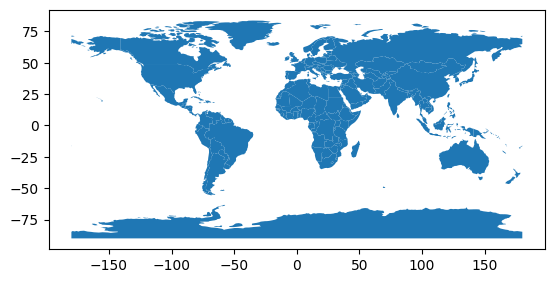

In [4]:
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

print(world.head())
world.plot()

# **Task 3: Check the Coordinate Reference System**
Guide Questions:
1. What does  EPSG:4326 represent?
2. Why is CRS important in spatial analysis?

In [5]:
print("Current CRS: ", world.crs)

Current CRS:  EPSG:4326


# **Task 4: Convert to Metric CRS for Area Calculation**
Guide Questions:
1. Why can't we compute area accurately using EPSG:4326?
2. What unit is EPSG:3857 based on?

In [6]:
world_projected = world.to_crs(epsg=3857)

world_projected["area_m2"] = world_projected.geometry.area

print(world_projected[["ADMIN", "area_m2"]].head())
print("\nArea Reprojection Complete")

                         ADMIN       area_m2
0                         Fiji  2.128334e+10
1  United Republic of Tanzania  9.522552e+11
2               Western Sahara  1.171023e+11
3                       Canada  5.216648e+13
4     United States of America  2.186228e+13

Area Reprojection Complete


# **Task 5: Extract Centroid Coordinates**
Guide Questions:
1. What is a centoid?
2. How can centroid coordinates be used in clustering?
3. Why do we extract X and Y separately?

In [7]:
world_projected["centroid"] = world_projected.geometry.centroid
world_projected["x"] = world_projected.centroid.x
world_projected["y"] = world_projected.centroid.y

print(world_projected[["ADMIN", "x", "y"]].head())

                         ADMIN             x             y
0                         Fiji  1.824878e+07 -1.958098e+06
1  United Republic of Tanzania  3.869296e+06 -7.003071e+05
2               Western Sahara -1.348403e+06  2.794163e+06
3                       Canada -1.079779e+07  1.044422e+07
4     United States of America -1.329713e+07  6.667416e+06


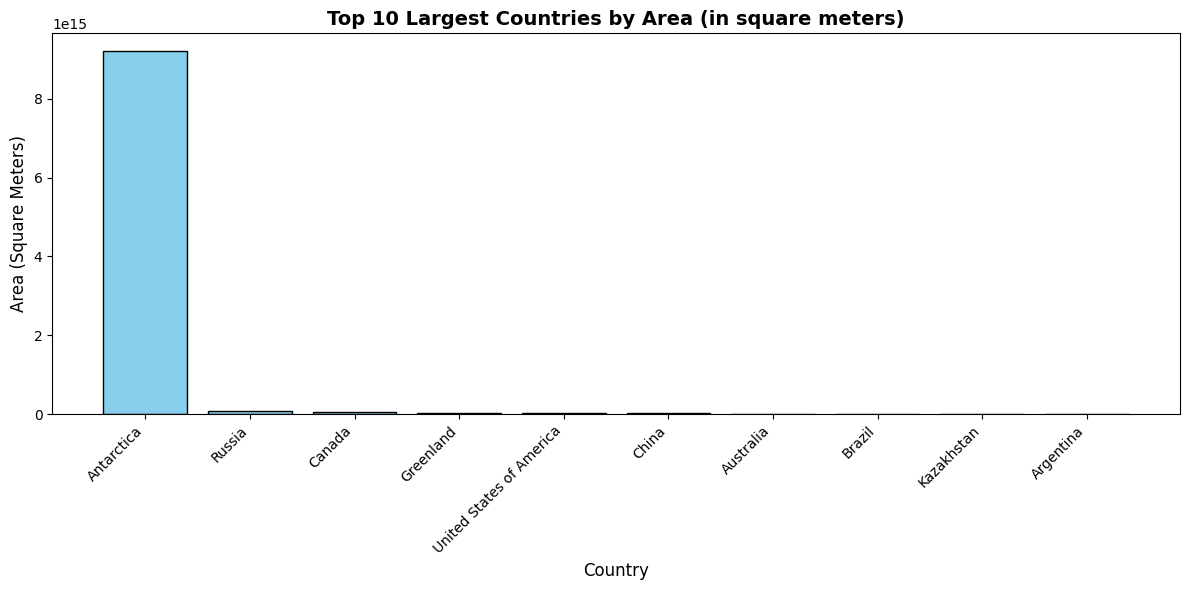

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Load the dataset (from Task 2)
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# 2. Convert to Metric CRS for Area Calculation (from Task 4)
world_projected = world.to_crs(epsg=3857)
world_projected["area_m2"] = world_projected.geometry.area

# 3. Sort to find the top 10 largest countries by area
top_10 = world_projected.sort_values(by="area_m2", ascending=False).head(10)

# 4. Plot the bar graph
plt.figure(figsize=(12, 6))
plt.bar(top_10["ADMIN"], top_10["area_m2"], color='skyblue', edgecolor='black')

# Formatting the graph
plt.title("Top 10 Largest Countries by Area (in square meters)", fontsize=14, fontweight='bold')
plt.xlabel("Country", fontsize=12)
plt.ylabel("Area (Square Meters)", fontsize=12)
plt.xticks(rotation=45, ha="right") # Rotate labels so they don't overlap
plt.tight_layout()

# Display the plot
plt.show()